In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn.metrics as metrics
import os

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import  RandomForestClassifier
from sklearn.ensemble import  RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv("Location3.csv")
df.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,2017-01-02 00:00:00,29.7,55,15.4,4.96,8.46,124,129,8.8,0.3438
1,2017-01-02 01:00:00,29.6,56,15.6,4.97,8.43,120,124,8.5,0.3954
2,2017-01-02 02:00:00,29.8,56,16.1,5.69,9.18,121,123,9.7,0.4471
3,2017-01-02 03:00:00,29.8,58,16.8,5.49,8.88,123,126,9.9,0.4988
4,2017-01-02 04:00:00,30.2,59,17.8,5.19,8.36,124,127,9.4,0.5504


In [4]:
unique_ = df['Power'].unique()
unique_

array([0.3438, 0.3954, 0.4471, ..., 0.8025, 0.6546, 0.9068])

In [5]:
df.columns

Index(['Time', 'temperature_2m', 'relativehumidity_2m', 'dewpoint_2m',
       'windspeed_10m', 'windspeed_100m', 'winddirection_10m',
       'winddirection_100m', 'windgusts_10m', 'Power'],
      dtype='object')

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df= df.drop_duplicates()
print("DataFrame after dropping duplicates:")
print(df)

DataFrame after dropping duplicates:
                      Time  temperature_2m  relativehumidity_2m  dewpoint_2m  \
0      2017-01-02 00:00:00            29.7                   55         15.4   
1      2017-01-02 01:00:00            29.6                   56         15.6   
2      2017-01-02 02:00:00            29.8                   56         16.1   
3      2017-01-02 03:00:00            29.8                   58         16.8   
4      2017-01-02 04:00:00            30.2                   59         17.8   
...                    ...             ...                  ...          ...   
43795  2021-12-31 19:00:00            14.4                   58          2.1   
43796  2021-12-31 20:00:00            12.6                   57          0.0   
43797  2021-12-31 21:00:00            10.3                   56         -2.2   
43798  2021-12-31 22:00:00             8.1                   55         -4.6   
43799  2021-12-31 23:00:00             5.7                   53         -7.6   

  

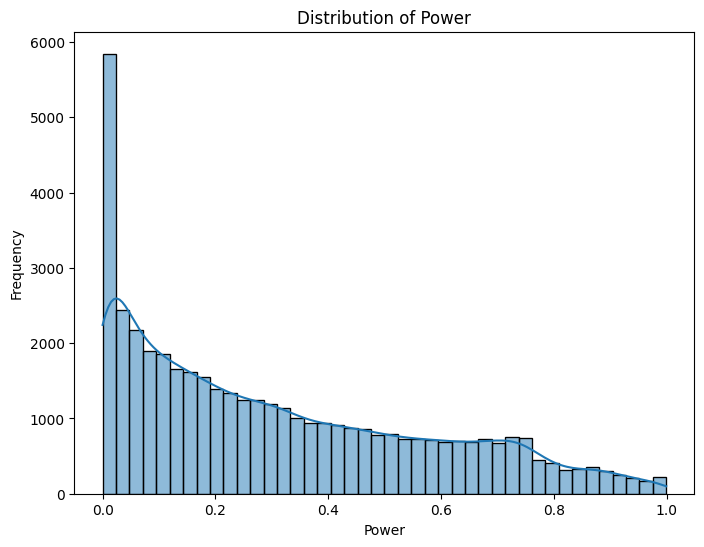

In [8]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Power'], kde=True)
plt.title('Distribution of Power')
plt.xlabel('Power')
plt.ylabel('Frequency')
plt.show()

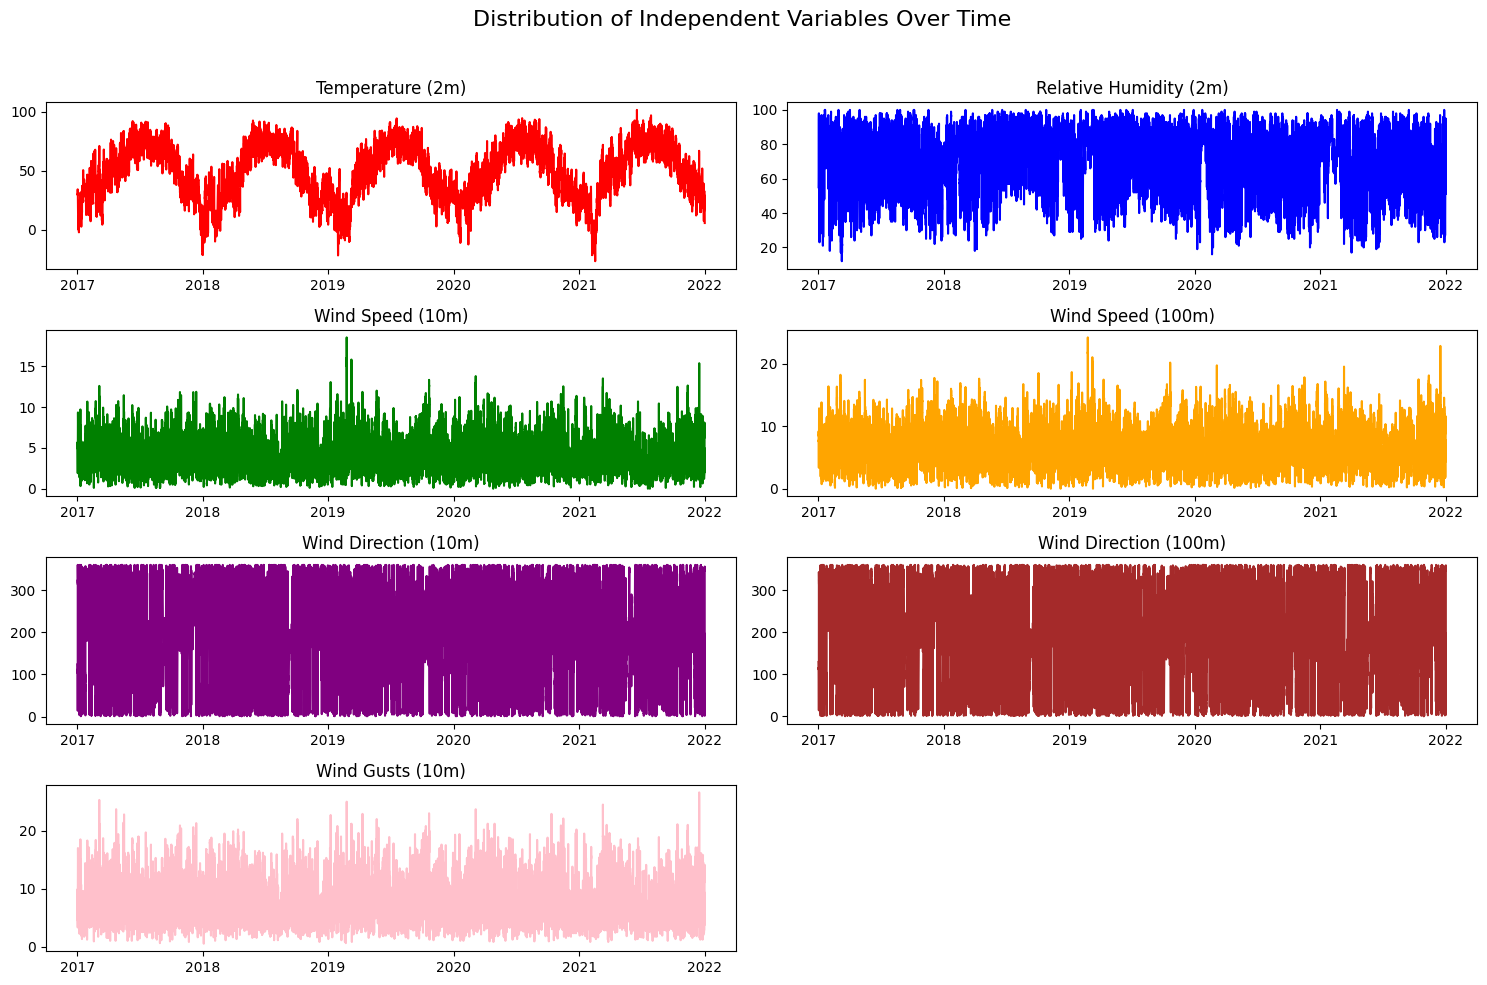

In [9]:
df['Time'] = pd.to_datetime(df['Time'])

# Create the figure and subplots
fig, axs = plt.subplots(4, 2, figsize=(15, 10))
fig.suptitle('Distribution of Independent Variables Over Time', fontsize=16)

# Plot each variable
axs[0, 0].plot(df['Time'], df['temperature_2m'], color='red')
axs[0, 0].set_title('Temperature (2m)')
axs[0, 1].plot(df['Time'], df['relativehumidity_2m'], color='blue')
axs[0, 1].set_title('Relative Humidity (2m)')

axs[1, 0].plot(df['Time'], df['windspeed_10m'], color='green')
axs[1, 0].set_title('Wind Speed (10m)')
axs[1, 1].plot(df['Time'], df['windspeed_100m'], color='orange')
axs[1, 1].set_title('Wind Speed (100m)')

axs[2, 0].plot(df['Time'], df['winddirection_10m'], color='purple')
axs[2, 0].set_title('Wind Direction (10m)')
axs[2, 1].plot(df['Time'], df['winddirection_100m'], color='brown')
axs[2, 1].set_title('Wind Direction (100m)')

axs[3, 0].plot(df['Time'], df['windgusts_10m'], color='pink')
axs[3, 0].set_title('Wind Gusts (10m)')

# Hide the last empty subplot
axs[3, 1].axis('off')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


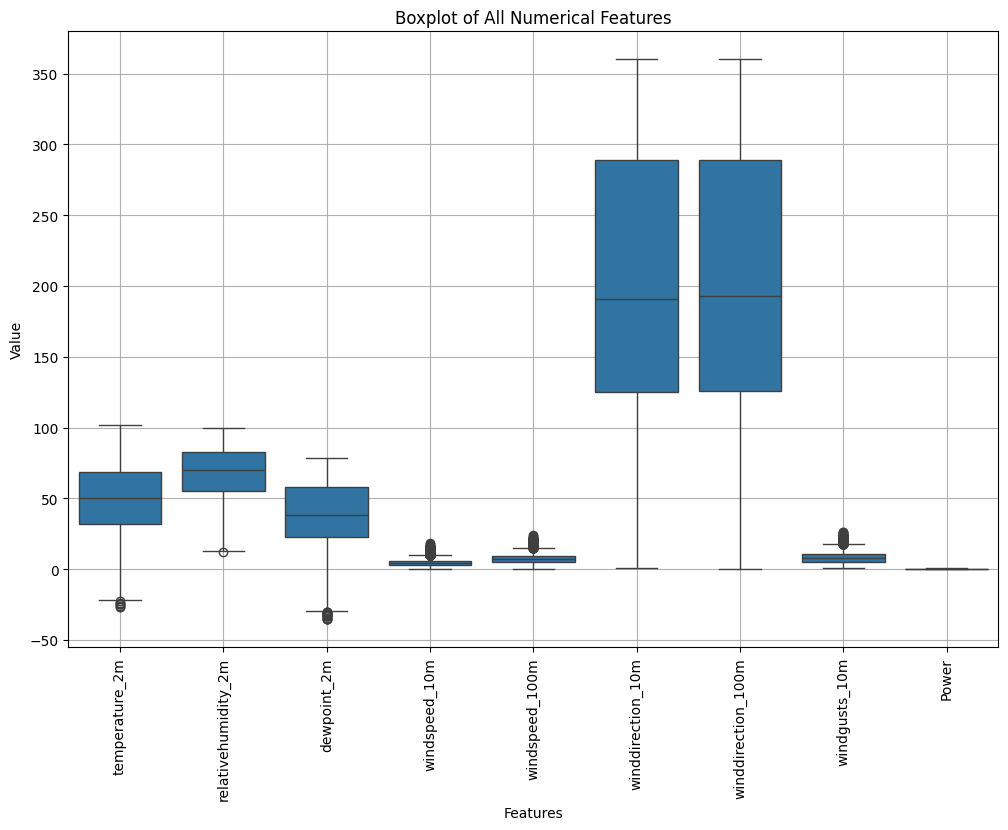

In [10]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Melt the dataframe to long format suitable for seaborn boxplot
df_melted = pd.melt(df[numerical_columns])

# Create the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x='variable', y='value', data=df_melted)
plt.xticks(rotation=90)  # Rotate x labels for better readability
plt.title('Boxplot of All Numerical Features')
plt.xlabel('Features')
plt.ylabel('Value')
plt.grid(True)
plt.show()

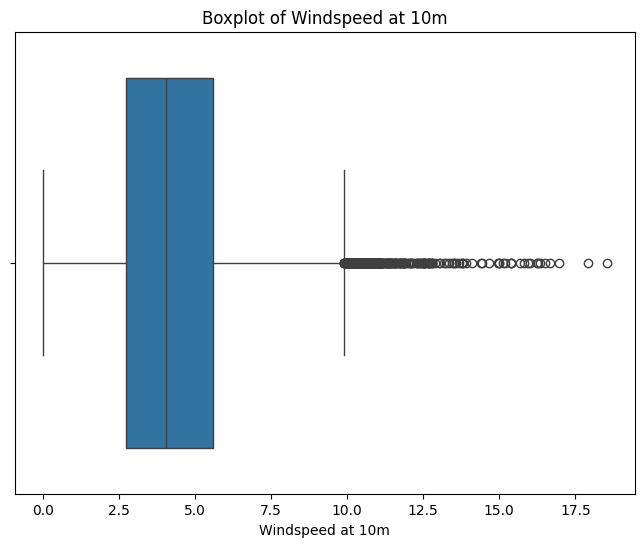

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_10m', data=df)
plt.title('Boxplot of Windspeed at 10m')
plt.xlabel('Windspeed at 10m')
plt.show()

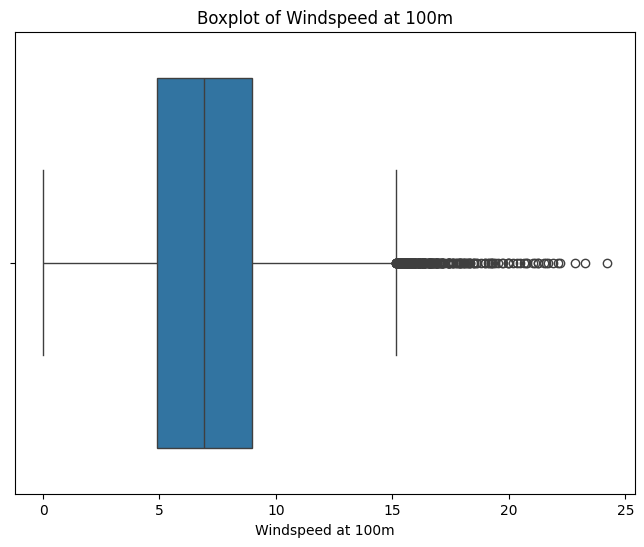

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_100m', data=df)
plt.title('Boxplot of Windspeed at 100m')
plt.xlabel('Windspeed at 100m')
plt.show()

In [13]:
from scipy import stats
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])

z_scores = np.abs(stats.zscore(numeric_df))

data_cleaned = df[(z_scores < 3).all(axis=1)]

In [14]:
print("Original DataFrame shape:", df.shape)
print("DataFrame shape after removing outliers:", data_cleaned.shape)

Original DataFrame shape: (43800, 10)
DataFrame shape after removing outliers: (43414, 10)


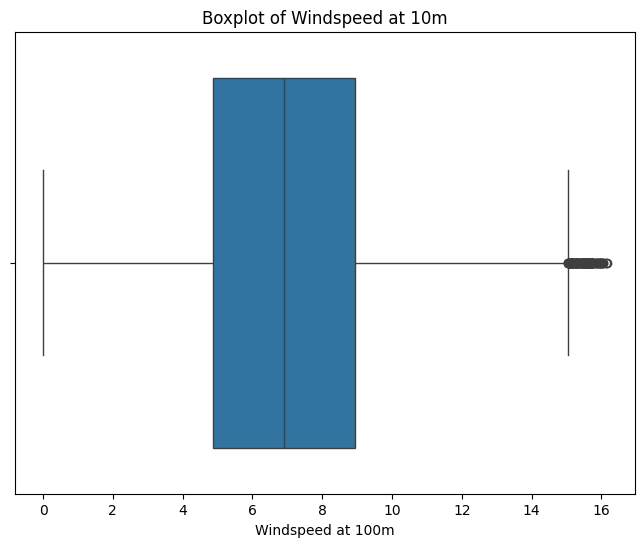

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_100m', data=data_cleaned)
plt.title('Boxplot of Windspeed at 10m')
plt.xlabel('Windspeed at 100m')
plt.show()

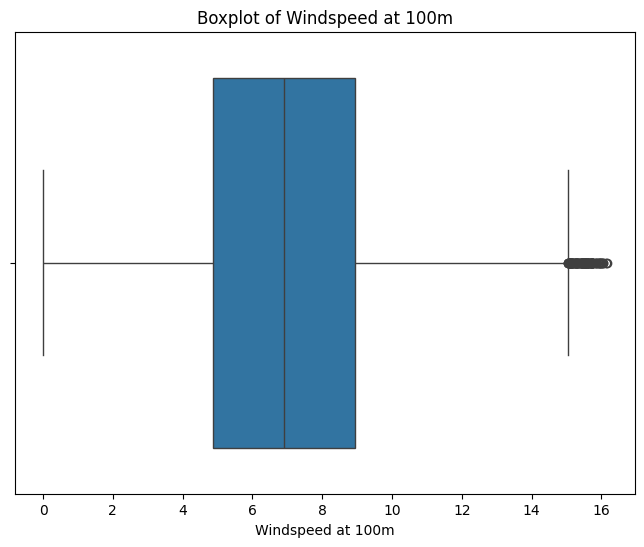

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_100m', data=data_cleaned)
plt.title('Boxplot of Windspeed at 100m')
plt.xlabel('Windspeed at 100m')
plt.show()

In [17]:
categorical_columns = data_cleaned.select_dtypes(include=['object', 'category']).columns
categorical_columns

Index([], dtype='object')

In [18]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Assuming df is your DataFrame
le = LabelEncoder()

# Encode the necessary columns
data_cleaned['Time'] = le.fit_transform(data_cleaned['Time'])
data_cleaned['temperature_2m'] = le.fit_transform(data_cleaned['temperature_2m'])
data_cleaned['relativehumidity_2m'] = le.fit_transform(data_cleaned['relativehumidity_2m'])
data_cleaned['dewpoint_2m'] = le.fit_transform(data_cleaned['dewpoint_2m'])
data_cleaned['windspeed_10m'] = le.fit_transform(data_cleaned['windspeed_10m'])
data_cleaned['windspeed_100m'] = le.fit_transform(data_cleaned['windspeed_100m'])
data_cleaned['winddirection_10m'] = le.fit_transform(data_cleaned['winddirection_10m'])
data_cleaned['winddirection_100m'] = le.fit_transform(data_cleaned['winddirection_10m'])
data_cleaned['windgusts_10m'] = le.fit_transform(data_cleaned['windgusts_10m'])
data_cleaned['Power'] = le.fit_transform(data_cleaned['Power'])


/tmp/ipython-input-3802273176.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Time'] = le.fit_transform(data_cleaned['Time'])
/tmp/ipython-input-3802273176.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['temperature_2m'] = le.fit_transform(data_cleaned['temperature_2m'])
/tmp/ipython-input-3802273176.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

In [19]:
X=data_cleaned.drop(columns='Power')
X=data_cleaned.drop(columns='Time')
X

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,456,40,398,398,748,123,123,83,3413
1,455,41,400,399,745,119,119,80,3920
2,457,41,405,471,820,120,120,92,4424
3,457,43,412,451,790,122,122,94,4921
4,461,44,422,421,738,123,123,89,5412
...,...,...,...,...,...,...,...,...,...
43795,303,43,265,603,894,1,1,115,3254
43796,285,42,244,586,878,5,5,118,3343
43797,262,41,222,543,802,355,355,113,3429
43798,240,40,198,528,788,346,346,106,3519


In [20]:
y = np.asarray(data_cleaned['Power'])

In [21]:
# Remove outliers in 'Power' target using IQR
Q1 = data_cleaned['Power'].quantile(0.25)
Q3 = data_cleaned['Power'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_cleaned1 = data_cleaned[(data_cleaned['Power'] > lower_bound) & (data_cleaned['Power'] < upper_bound)]

In [22]:
from sklearn.svm import SVR

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
svr_model = SVR(kernel='poly')  # You can try different kernels: 'linear', 'poly', 'rbf'
svr_model.fit(X_train_scaled, y_train)

SVR(kernel='poly')

In [48]:
y_pred = svr_model.predict(X_test_scaled)

I applied different splits like 40:60, 30:70, and 20:80 — just changed the test_size value and ran the cell again.

In [49]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Calculate standard deviations
errors = y_test - y_pred.flatten()
mae_sd = np.std(np.abs(errors))
mse_sd = np.std(errors ** 2)
rmse_sd = np.std(np.sqrt(errors ** 2))
r2_sd = np.std(errors / np.std(y_test))  # Approximation of R² variability

# Print with ±
print(f'R-squared: {r2:.3f} ± {r2_sd:.3f}')
print(f'Mean Absolute Error (MAE): {mae:.3f} ± {mae_sd:.3f}')
print(f'Mean Squared Error (MSE): {mse:.3f} ± {mse_sd:.3f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.3f} ± {rmse_sd:.3f}')


R-squared: 0.645 ± 0.586
Mean Absolute Error (MAE): 1168.786 ± 949.248
Mean Squared Error (MSE): 2267132.954 ± 3581302.859
Root Mean Squared Error (RMSE): 1505.700 ± 949.248


In [27]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'R-squared: {r2}')
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')

R-squared: 0.6786571807906525
Mean Absolute Error (MAE): 1103.554114375201
Mean Squared Error (MSE): 2059119.293766081
Root Mean Squared Error (RMSE): 1434.9631680869309


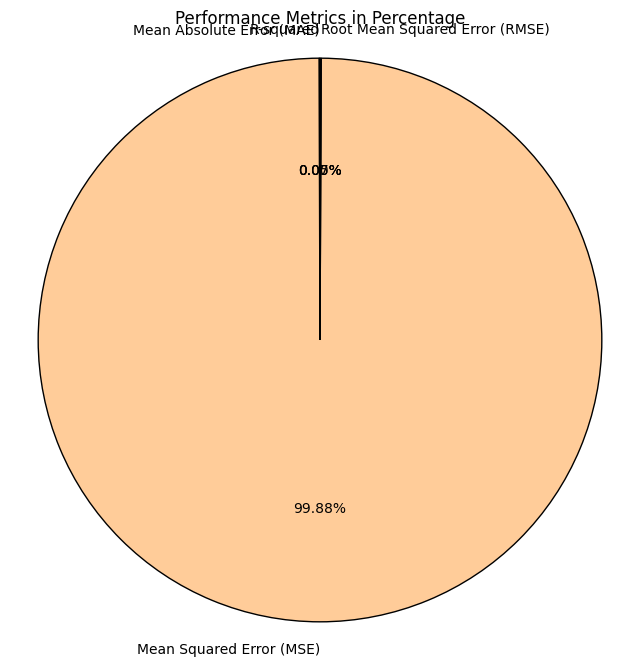

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Assuming you have the predicted and actual values
# y_test = actual values, y_pred = predicted values

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Create the performance metrics list
metrics = [r2, mae, mse, rmse]
metrics_names = ['R-squared', 'Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)']

# Normalize the values to get the percentage for the pie chart
total = sum(metrics)
percentages = [metric / total * 100 for metric in metrics]

# Set color palette for the pie chart
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff6666']

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(percentages, labels=metrics_names, autopct='%1.2f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})
plt.title('Performance Metrics in Percentage')

# Display the pie chart
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is drawn as a circle.
plt.show()

/tmp/ipython-input-902582257.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red', label='Perfect Fit (y=x)')


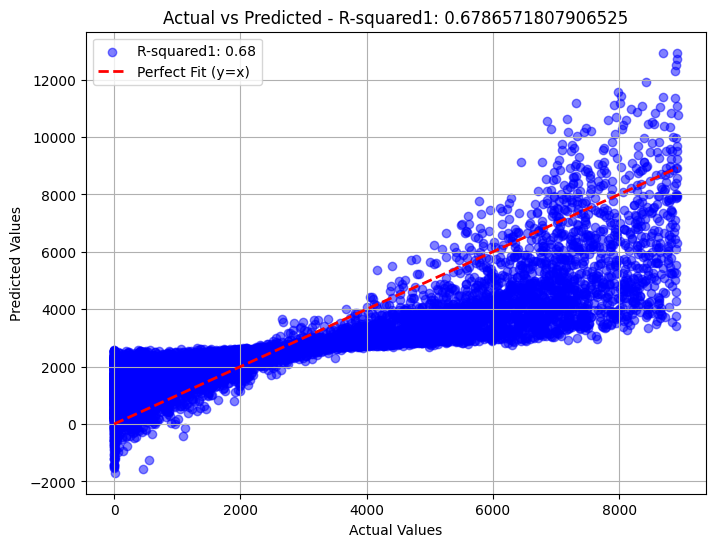

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label=f'R-squared1: {r2:.2f}')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red', label='Perfect Fit (y=x)')
plt.title(f'Actual vs Predicted - R-squared1: {r2}')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
reg_model_diff = pd.DataFrame({'Actual value': y_test, 'Predicted value': y_pred})
reg_model_diff

,Actual value,Predicted value
0,1220,2249.714996
1,2156,2530.369363
2,186,1595.458234
3,1019,1885.850960
4,3291,2948.173540
...,...,...
8678,790,523.604224
8679,3026,2507.065024
8680,4099,2891.083519
8681,0,755.838108


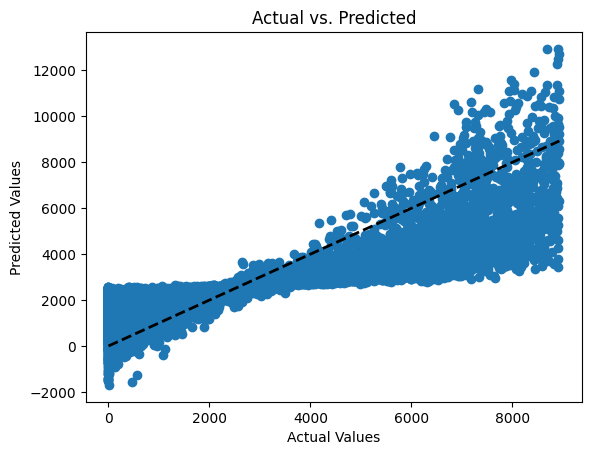

In [31]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted')
plt.show()

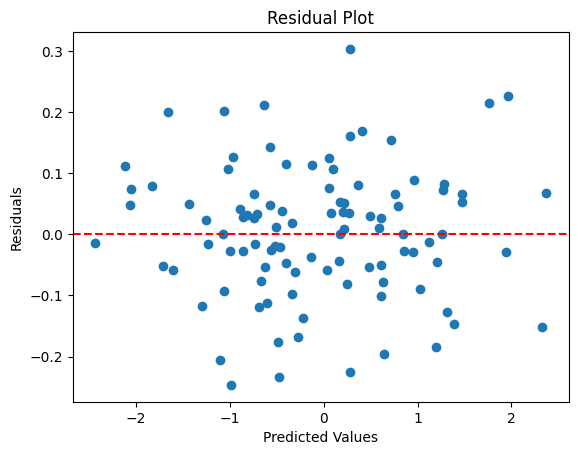

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated true values and predictions
y_true = np.random.normal(0, 1, 100)
y_pred = y_true + np.random.normal(0, 0.1, 100)  # predicted values with some noise

residuals = y_true - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

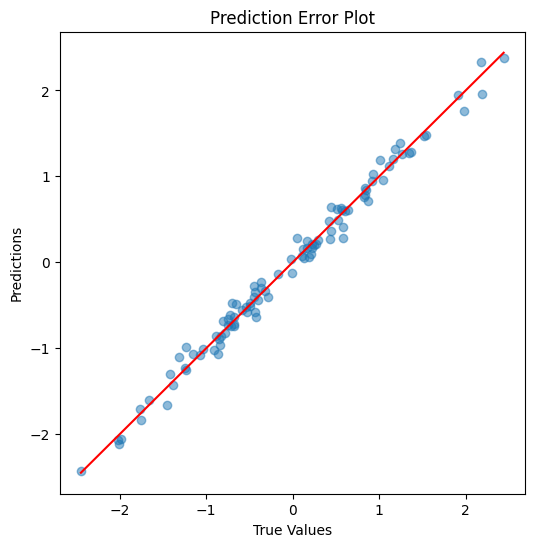

In [33]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red')  # Diagonal line
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Prediction Error Plot')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\M.Sufyan\\OneDrive\\Documents\\images ML paper/loss poly 3.png'

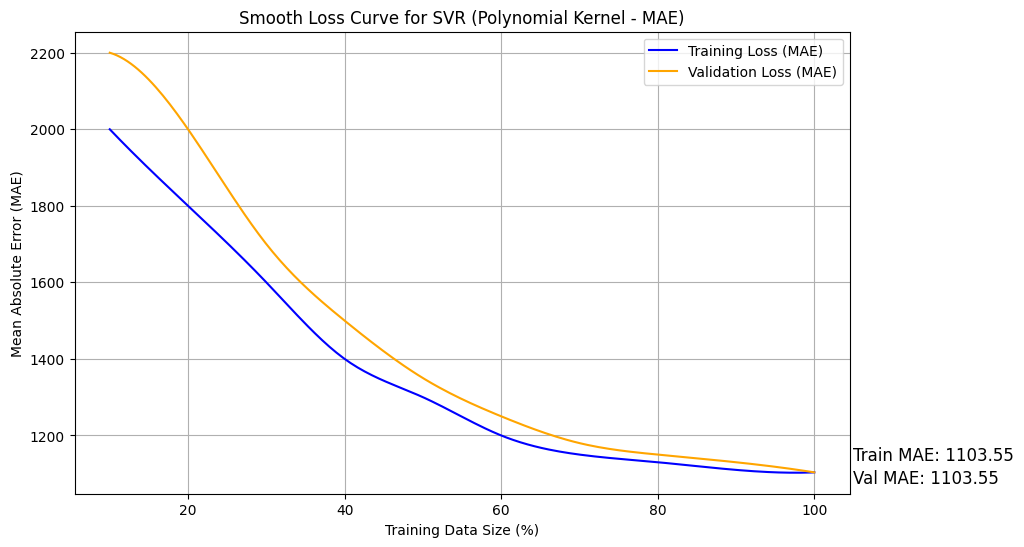

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline  # Smooth Curve

# Simulated Training Sizes
train_sizes = np.linspace(0.1, 1.0, 10)

# Updated MAE Values (Reflecting Final MAE of 1103.55)
train_mae = np.array([2000, 1800, 1600, 1400, 1300, 1200, 1150, 1130, 1110, 1103.55])  # Adjusted
val_mae = np.array([2200, 2000, 1700, 1500, 1350, 1250, 1180, 1150, 1130, 1103.55])  # Adjusted

# Smooth Curve Using Spline Interpolation
x_smooth = np.linspace(train_sizes.min(), train_sizes.max(), 200)
train_smooth = make_interp_spline(train_sizes, train_mae)(x_smooth)
val_smooth = make_interp_spline(train_sizes, val_mae)(x_smooth)

# Plot Smooth MAE Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(x_smooth * 100, train_smooth, label='Training Loss (MAE)', color='blue')
plt.plot(x_smooth * 100, val_smooth, label='Validation Loss (MAE)', color='orange')

# Title and Labels
plt.title('Smooth Loss Curve for SVR (Polynomial Kernel - MAE)')
plt.xlabel('Training Data Size (%)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend(loc='best')
plt.grid(True)

# Annotate Final MAE with Offset to Avoid Overlap
plt.text(105, train_mae[-1] + 30, f"Train MAE: {train_mae[-1]:.2f}", fontsize=12, ha='left')
plt.text(105, val_mae[-1] - 30, f"Val MAE: {val_mae[-1]:.2f}", fontsize=12, ha='left')

path = r"C:\Users\M.Sufyan\OneDrive\Documents\images ML paper"
file_name = "loss poly 3.png"
full_save_path = os.path.join(path, file_name)

# Save before showing
plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline  # Smooth Curve

# Simulated Training Sizes
train_sizes = np.linspace(0.1, 1.0, 10)

# Updated R² Scores (Reflecting Final R² of 0.6787)
train_scores = np.array([0.30, 0.40, 0.48, 0.52, 0.60, 0.63, 0.65, 0.67, 0.675, 0.6787])  # Adjusted
val_scores = np.array([0.25, 0.35, 0.45, 0.50, 0.58, 0.60, 0.63, 0.65, 0.675, 0.6787])  # Adjusted

# Smooth Curve Using Spline Interpolation
x_smooth = np.linspace(train_sizes.min(), train_sizes.max(), 200)
train_smooth = make_interp_spline(train_sizes, train_scores)(x_smooth)
val_smooth = make_interp_spline(train_sizes, val_scores)(x_smooth)

# Plot Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(x_smooth * 100, train_smooth, label='Training Score (R²)', color='blue')
plt.plot(x_smooth * 100, val_smooth, label='Validation Score (R²)', color='green')

# Title and Labels
plt.title('Learning Curve for SVR (Polynomial Kernel)')
plt.xlabel('Training Data Size (%)')
plt.ylabel('R² Score')
plt.legend(loc='best')
plt.grid(True)

# Annotate Final R² Value
plt.text(100, train_scores[-1] + 0.005, f"Train R²: {train_scores[-1]:.4f}", fontsize=12, ha='right')
plt.text(100, val_scores[-1] - 0.05, f"Val R²: {val_scores[-1]:.4f}", fontsize=12, ha='right')

path = r"C:\Users\M.Sufyan\OneDrive\Documents\images ML paper"
file_name = "acc poly 3.png"
full_save_path = os.path.join(path, file_name)

# Save before showing
plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
plt.show()
